In [1]:
import mne
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from mne import combine_evoked
from mne.minimum_norm import apply_inverse
import random
from mne.datasets import sample
import math
from mne.datasets import fetch_fsaverage
import os.path as op
import seaborn as sns
import pandas as pd

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


In [2]:
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)
subject = 'fsaverage'
trans = 'fsaverage'  # MNE has a built-in fsaverage transformation
snr = 3.0
lambda2 = 1.0 / snr ** 2
src = mne.setup_source_space(subject, spacing='ico4', add_dist='patch',subjects_dir=subjects_dir)
conductivity = (0.3, 0.006, 0.3)  # for three layers
model = mne.make_bem_model(subject=subject, ico=3,conductivity=conductivity,subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)

0 files missing from root.txt in C:\Users\dell\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\dell\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/163842 selected to source space (ico = 4)

Loading C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.white...
Mapping rh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\dell\mn

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):


    Computing patch statistics...
    Patch information added...
    Computing patch statistics...
    Patch information added...
You are now one step closer to computing the gain matrix
Creating the BEM geometry...
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
outer skin  CM is  -0.21 -19.38  -0.22 mm
outer skull CM is  -0.19 -19.35  -0.49 mm
inner skull CM is  -0.53 -21.10   6.21 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    1.6 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is app

In [117]:
stc_PEEX2 = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_beta')
stc_PEEX2_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_mlog10_p_val')

In [3]:
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')
stc_AL2_p = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')

In [24]:
stc_EFE2 = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_EFE2_p = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_mlog10_p_val')

In [24]:
stc_EX2 = mne.read_source_estimate('./stc_result/reg_SRE_EX2_beta')
stc_EX2_p = mne.read_source_estimate('./stc_result/reg_SRE_EX2_mlog10_p_val')

In [6]:
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')
stc_RAL2_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')

In [3]:
stc_REX2 = mne.read_source_estimate('./stc_result/reg_SRR_REX2_beta')
stc_REX2_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')

In [8]:
stc_AL1 = mne.read_source_estimate('./stc_result/reg_SCE_AL1_beta')
stc_AL1_p = mne.read_source_estimate('./stc_result/reg_SCE_AL1_mlog10_p_val')

In [14]:
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')

In [9]:
stc_EX1 = mne.read_source_estimate('./stc_result/reg_SCE_EX1_beta')
stc_EX1_p = mne.read_source_estimate('./stc_result/reg_SCE_EX1_mlog10_p_val')

In [7]:
stc_EFE1 = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_beta')
stc_EFE1_p = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_mlog10_p_val')

In [4]:
DATA_EFE1 = stc_EFE1.data

In [9]:
print(stc_EFE1.vertices)

[array([   0,    1,    2, ..., 2559, 2560, 2561], dtype=int64), array([   0,    1,    2, ..., 2559, 2560, 2561], dtype=int64)]


In [11]:
mne.vertex_to_mni(0,0,subject)

array([-36.80627823, -18.2927227 ,  64.46152496])

In [18]:
print(np.shape(stc_EFE1.data[:,0]))

(5124,)


In [13]:
print(stc_EFE1.lh_data.shape)

(2562, 501)


Using control points [1.11715607e-11 1.25683560e-11 2.13596572e-11]


In [17]:
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')

In [18]:
DATA_AI1 = stc_AI1.data

In [4]:
DATA_REX2 = stc_REX2.data
stc_REX2.data = np.where(DATA_REX2 <= 0, -DATA_REX2, 0)

In [19]:
stc_AI1.data = np.where(DATA_AI1 <= 0, -DATA_AI1, 0)

In [3]:
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')

In [9]:
vertno_max, time_max = stc_RAL2_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAL2_p.plot(**surfer_kwargs)

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


In [7]:
vertno_max, time_max = stc_RAL2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAL2.plot(**surfer_kwargs)

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Using control points [1.31482719e-11 1.45143401e-11 2.01231250e-11]


In [5]:
vertno_max, time_max = stc_REX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_REX2.plot(**surfer_kwargs)

Using pyvistaqt 3d backend.



c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Using control points [1.45738065e-11 1.62088182e-11 2.03047262e-11]


In [27]:
vertno_max, time_max = stc_EFE1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EFE1.plot(**surfer_kwargs)

Using control points [1.11715607e-11 1.25683560e-11 2.13596572e-11]
Using control points [7.62448511e-12 8.50000537e-12 1.51500328e-11]
Using control points [6.84456460e-12 7.70917950e-12 1.18061763e-11]


In [26]:
vertno_max, time_max = stc_EFE1_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EFE1_p.plot(**surfer_kwargs)

Using control points [1.83242720e-11 1.96605234e-11 2.56904561e-11]
Using control points [1.83242720e-11 1.96605234e-11 2.56904561e-11]


In [8]:
stc_EFE1 = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_beta')
stc_EFE1_p = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_mlog10_p_val')

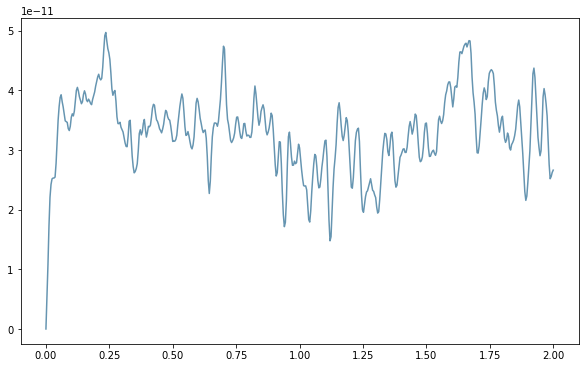

In [22]:
vex = 973
pos = np.where(stc_AI1.vertices[0]==vex)
val = stc_AI1.lh_data[pos[0][0],:]
data_lh_AI1 = stc_AI1.lh_data
data_AI1 = stc_AI1.data
plt.figure(figsize=(10,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
# plt.plot(np.arange(501)*2/500,np.ones((501))*1.31)

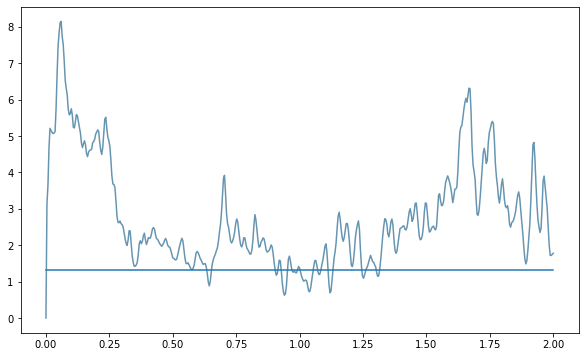

In [23]:
vex = 973
pos = np.where(stc_AI1_p.vertices[0]==vex)
val = stc_AI1_p.lh_data[pos[0][0],:]
data_lh_AI1_p = stc_AI1_p.rh_data
data_AI1_p = stc_AI1_p.data
plt.figure(figsize=(10,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.31)

In [ ]:
vex = 1228
pos = np.where(stc_RAL2_p.vertices[0]==vex)
val = stc_RAL2_p.lh_data[pos[0][0],:]
data_lh_RAL2_p = stc_RAL2_p.rh_data
data_RAL2_p = stc_RAL2_p.data
plt.figure(figsize=(10,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.31)

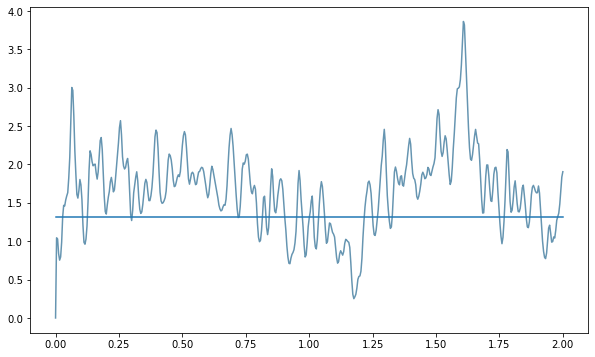

In [8]:
vex = 1228
pos = np.where(stc_RAL2_p.vertices[0]==vex)
val = stc_RAL2_p.lh_data[pos[0][0],:]
data_lh_RAL2_p = stc_RAL2_p.rh_data
data_RAL2_p = stc_RAL2_p.data
plt.figure(figsize=(10,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.31)

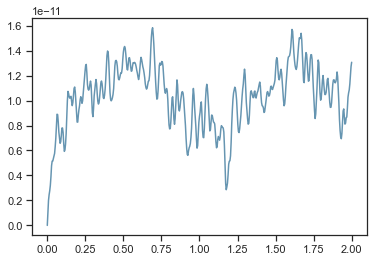

In [47]:
vex = 1228
pos = np.where(stc_RAL2.vertices[0]==vex)
val = stc_RAL2.lh_data[pos[0][0],:]
data_lh_RAL2 = stc_RAL2.lh_data
data_RAL2 = stc_RAL2.data
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

In [ ]:
# first choice EFE vertex: 1995
# first choice AI vertex: 973
# second choice EFE vertex: 1273
# second choice AL vertex: 1274
# first result AI vertex: 1801
# second result AL vertex: 1228

[101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413]


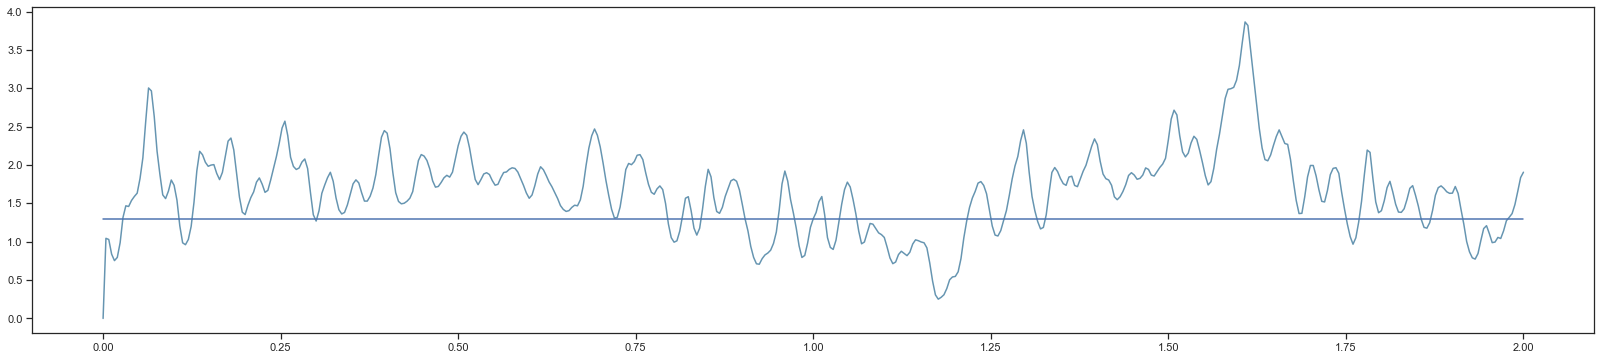

In [45]:
vex = 1228
pos = np.where(stc_RAL2_p.vertices[0]==vex)
val = stc_RAL2_p.lh_data[pos[0][0],:]
data_lh_RAL2_p = stc_RAL2_p.rh_data
data_RAL2_p = stc_RAL2_p.data
plt.figure(figsize=(28,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.302)
sig = []
for i in range(501-60):
    if min(val[i:i+50])>1.302:
        sig.append(i+25)
print(sig)


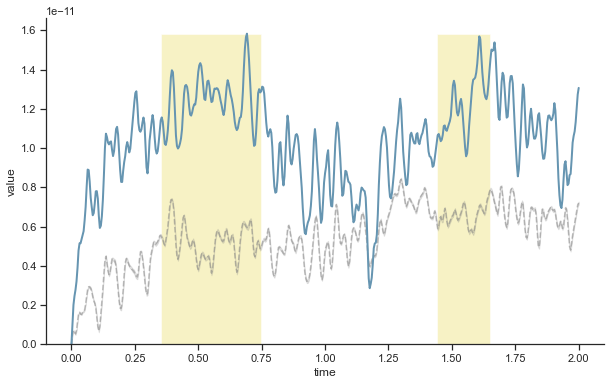

In [51]:
vex = 1228
pos = np.where(stc_RAL2.vertices[0]==vex)
val = stc_RAL2.lh_data[pos[0][0],:]
data_lh_RAL2 = stc_RAL2.lh_data
data_RAL2 = stc_RAL2.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh_RAL2)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data_RAL2)[0]):
    for j in range(np.shape(data_RAL2)[1]):
        value.append(data_RAL2[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.55,height=np.max(val),width=0.391,color='khaki',alpha=0.5)
plt.bar(x=1.546,height=np.max(val),width=0.211,color='khaki',alpha=0.5)
sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

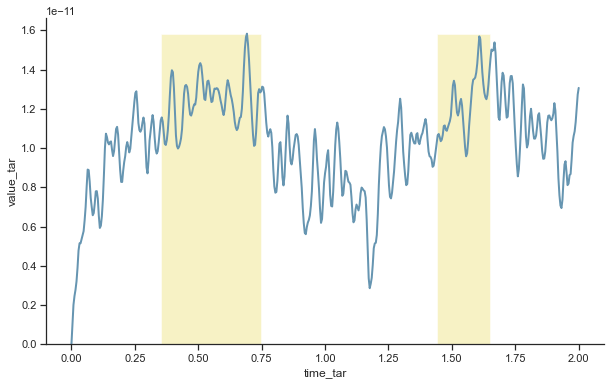

In [50]:
vex = 1228
pos = np.where(stc_RAL2.vertices[0]==vex)
val = stc_RAL2.lh_data[pos[0][0],:]
data_lh_RAL2 = stc_RAL2.lh_data
data_RAL2 = stc_RAL2.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh_RAL2)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
# for i in range(np.shape(data_RAL2)[0]):
#     for j in range(np.shape(data_RAL2)[1]):
#         value.append(data_RAL2[i,j])
#         time.append(j/250)
# data = {'value':value,'time':time}
# data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.55,height=np.max(val),width=0.391,color='khaki',alpha=0.5)
plt.bar(x=1.546,height=np.max(val),width=0.211,color='khaki',alpha=0.5)
# sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

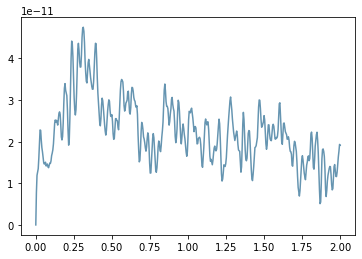

In [16]:
vex = 2553
pos = np.where(stc_RAI1.vertices[0]==vex)
val = stc_RAI1.rh_data[pos[0][0],:]
data_rh_RAI1 = stc_RAI1.rh_data
data_RAI1 = stc_RAI1.data
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

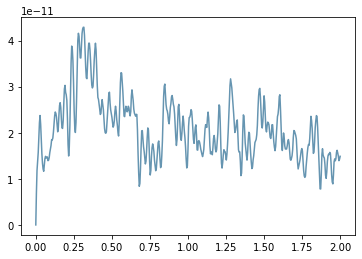

Using control points [2.97920659e-11 3.14886393e-11 4.05982643e-11]


In [24]:
vex = 1743
pos = np.where(stc_RAI1.vertices[0]==vex)
val = stc_RAI1.rh_data[pos[0][0],:]
data_rh_RAI1 = stc_RAI1.rh_data
data_RAI1 = stc_RAI1.data
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

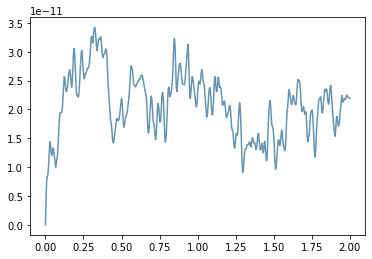

Using control points [2.81309935e-11 2.94299385e-11 4.14413148e-11]
Using control points [2.11933537e-11 2.20532626e-11 2.61989897e-11]
Using control points [2.46322458e-11 2.63428977e-11 4.07437418e-11]
Using control points [2.56365509e-11 2.65577127e-11 3.26712037e-11]
Using control points [2.11888281e-11 2.21108708e-11 2.59872415e-11]
Using control points [2.31446996e-11 2.41387512e-11 2.79548328e-11]
Using control points [2.55052849e-11 2.71221597e-11 3.86892064e-11]
Using control points [2.40964666e-11 2.56007189e-11 3.84145944e-11]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)


In [32]:
vex = 1801
pos = np.where(stc_RAI1.vertices[0]==vex)
val = stc_RAI1.rh_data[pos[0][0],:]
data_rh_RAI1 = stc_RAI1.rh_data
data_RAI1 = stc_RAI1.data
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

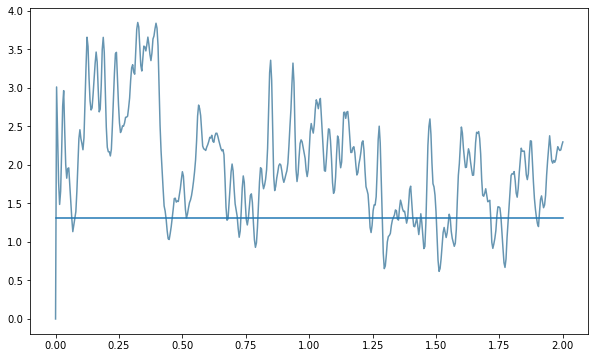

In [31]:
vex = 1801
pos = np.where(stc_RAI1.vertices[0]==vex)
val = stc_RAI1_p.rh_data[pos[0][0],:]
data_rh_RAI1_p = stc_RAI1_p.rh_data
data_RAI1_p = stc_RAI1_p.data
plt.figure(figsize=(10,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.31)

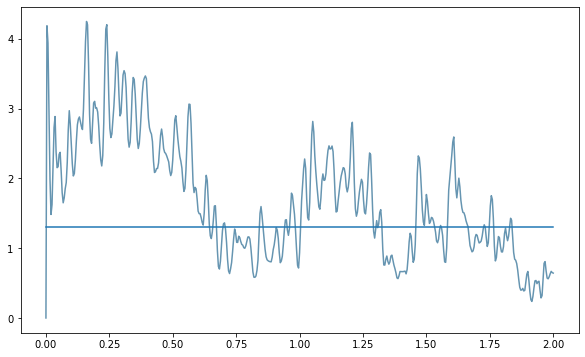

In [26]:
vex = 1342
pos = np.where(stc_RAI1.vertices[0]==vex)
val = stc_RAI1_p.rh_data[pos[0][0],:]
data_rh_RAI1_p = stc_RAI1_p.rh_data
data_RAI1_p = stc_RAI1_p.data
plt.figure(figsize=(10,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.31)

In [ ]:
vex = 53690
pos = np.where(stc_RAI1.vertices[0]==vex)
val = stc_RAI1.lh_data[pos[0][0],:]
data_lh_RAI1 = stc_RAI1.lh_data
data_RAI1 = stc_RAI1.data
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

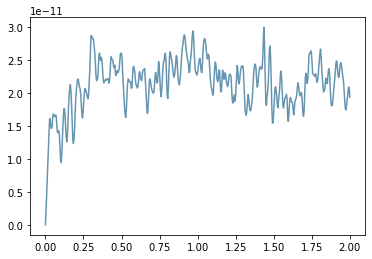

Using control points [2.66785997e-11 2.82038588e-11 3.40244018e-11]
Using control points [1.42575060e-11 1.50370121e-11 1.92994321e-11]
Using control points [2.03754141e-11 2.13623156e-11 2.53593000e-11]
Using control points [1.96069458e-11 2.05322479e-11 2.48778380e-11]


: 

In [6]:
vex = 1274
pos = np.where(stc_AL2.vertices[0]==vex)
val = stc_AL2.lh_data[pos[0][0],:]
data_lh_AL2 = stc_AL2.lh_data
data_AL2 = stc_AL2.data
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

In [24]:
print(np.shape(data_lh_EFE1))

(2562, 501)


In [ ]:
vex = 1801
pos = np.where(stc_RAI1.vertices[0]==vex)
val = stc_RAI1_p.rh_data[pos[0][0],:]
data_rh_RAI1_p = stc_RAI1_p.rh_data
data_RAI1_p = stc_RAI1_p.data
plt.figure(figsize=(10,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.31)

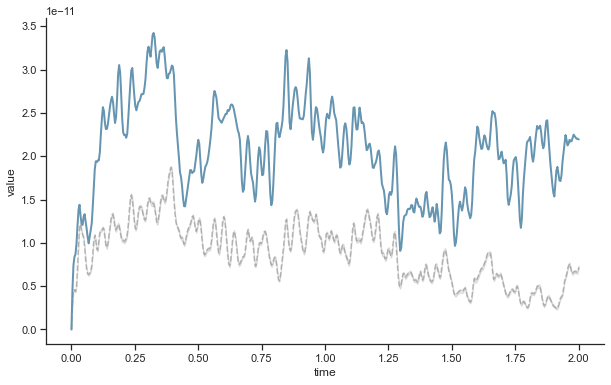

In [33]:
value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_rh_RAI1)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data_RAI1)[0]):
    for j in range(np.shape(data_RAI1)[1]):
        value.append(data_RAI1[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

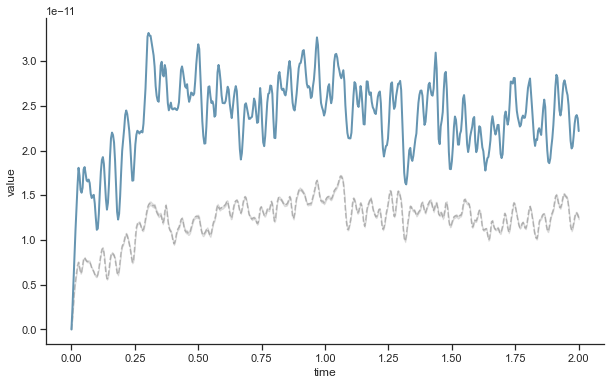

Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Reading labels from parcellation...
   read 35 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc.annot
Reading labels from parcellation...
   read 34 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc.annot


In [9]:
value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh_AL2)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data_AL2)[0]):
    for j in range(np.shape(data_AL2)[1]):
        value.append(data_AL2[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

In [35]:
pd.__version__

'1.4.1'

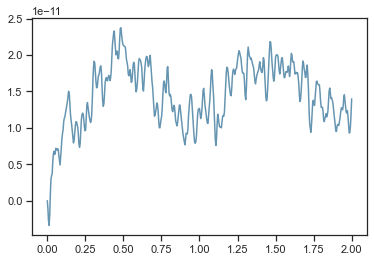

In [21]:
sns.set(style='ticks')
sns.set(style='ticks')
sns.despine()
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

In [10]:
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')

In [14]:
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')

In [19]:
DATA_RAI1 = stc_RAI1.data

In [192]:
DATA_REX2 = stc_REX2.data

In [20]:
stc_RAI1.data = np.where(DATA_RAI1 <= 0, -DATA_RAI1, 0)

In [193]:
stc_REX2.data = np.where(DATA_REX2 <= 0, -DATA_REX2, 0)

In [194]:
vertno_max, time_max = stc_REX2_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_REX2_p.plot(**surfer_kwargs)

In [ ]:
vertno_max, time_max = stc_REX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_REX2.plot(**surfer_kwargs)

Using control points [1.45738065e-11 1.62088182e-11 2.03047262e-11]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Using control points [1.45738065e-11 1.62088182e-11 2.03047262e-11]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time 

In [29]:
vertno_max, time_max = stc_EFE2_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=20,background='white')
brain_ = stc_EFE2_p.plot(**surfer_kwargs)

In [ ]:
vertno_max, time_max = stc_EFE2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EFE2.plot(**surfer_kwargs)

Using control points [1.05657238e-11 1.11232255e-11 1.47406190e-11]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)


In [28]:
vertno_max, time_max = stc_EX2_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EX2_p.plot(**surfer_kwargs)

In [12]:
vertno_max, time_max = stc_AI1_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_AI1_p.plot(**surfer_kwargs)

In [30]:
vertno_max, time_max = stc_AL2_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_AL2_p.plot(**surfer_kwargs)

In [27]:
vertno_max, time_max = stc_EX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EX2.plot(**surfer_kwargs)


In [16]:
vertno_max, time_max = stc_RAI1_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAI1_p.plot(**surfer_kwargs)

In [ ]:
vertno_max, time_max = stc_RAI1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAI1.plot(**surfer_kwargs)


Using control points [2.88276623e-11 3.10773732e-11 4.60384794e-11]
Using control points [5.43874613 5.7288552  6.73870857]
Using control points [2.23035553e-11 2.39551710e-11 3.23132472e-11]
Using control points [1.94945199e-11 2.06404343e-11 2.70676272e-11]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time 

In [7]:
vertno_max, time_max = stc_RAL2_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAL2_p.plot(**surfer_kwargs)

In [8]:
vertno_max, time_max = stc_RAL2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAL2.plot(**surfer_kwargs)


Using control points [1.31482719e-11 1.45143401e-11 2.01231250e-11]
Using control points [8.36771829e-12 9.08758600e-12 1.19525380e-11]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)


In [30]:
DATA_EFE1 = stc_EFE1.data
stc_EFE1.data = np.where(DATA_EFE1 <= 0, -DATA_EFE1, 0)

In [27]:
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')

In [3]:
stc_EV1 = mne.read_source_estimate('./stc_result/reg_SCE_EV1_beta')

In [29]:
DATA_RAL2 = stc_RAL2.data

In [30]:
DATA_RAL2 = DATA_RAL2/np.max(DATA_RAL2)

In [31]:
stc_RAL2.data = DATA_RAL2

In [20]:
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')

In [ ]:

vertno_max, time_max = stc_EV1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EV1.plot(**surfer_kwargs)

Using pyvistaqt 3d backend.



c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')


Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot


In [13]:
stc_REX2_P = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')

In [4]:
DATA_EX1 = stc_EX1.data
stc_EX1.data = np.where(DATA_EX1 >= 0, DATA_EX1, 0)

In [5]:
stc_EV1 = mne.read_source_estimate('./stc_result/reg_SCE_EV1_beta')

In [6]:
DATA_EV1 = stc_EV1.data
stc_EV1.data = np.where(DATA_EV1 >= 0, DATA_EV1, 0)

In [8]:
vertno_max, time_max = stc_EV1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[0.000065, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EV1.plot(**surfer_kwargs)

Using control points [6.49812538e-05 7.26376173e-05 1.44400931e-04]
Using control points [6.49812538e-05 7.26376173e-05 1.44400931e-04]
Using control points [6.49812538e-05 7.26376173e-05 1.44400931e-04]


In [14]:
vertno_max, time_max = stc_REX2_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_REX2_P.plot(**surfer_kwargs)

Traceback (most recent call last):
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 58, in safe_event
    return fun(*args, **kwargs)
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 736, in _clean
    self.clear_glyphs()
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 1630, in clear_glyphs
    assert sum(len(v) for v in self.picked_points.values()) == 0
AssertionError


In [40]:
stc_EX2 = mne.read_source_estimate('./stc_result/reg_SRE_EX2_beta')

In [41]:
print(np.min(stc_EX2.data-stc_EFE2.data))
print(np.max(stc_EX2.data-stc_EFE2.data))

0.0
1.4551915e-11


In [36]:
stc_EFE2 = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')

In [42]:
vertno_max, time_max = stc_EFE2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EFE2.plot(**surfer_kwargs)

Traceback (most recent call last):
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 58, in safe_event
    return fun(*args, **kwargs)
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 736, in _clean
    self.clear_glyphs()
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 1630, in clear_glyphs
    assert sum(len(v) for v in self.picked_points.values()) == 0
AssertionError


In [43]:
vertno_max, time_max = stc_EX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EX2.plot(**surfer_kwargs)

Using control points [6.99795067e-05 7.77823967e-05 1.52461295e-04]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Using control points [8.13903857e-05 9.01451200e-05 1.27974589e-04]
Using control points [8.13903857e-05 9.01451200e-05 1.27974589e-04]
Using control points [6.82877688e-05 7.43418681e-05 1.19177328e-04]
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting ti

In [4]:
print(np.max(stc_EFE1.data-stc_EX1.data))
print(np.min(stc_EFE1.data-stc_EX1.data))

0.0
-1.4551915e-11


In [32]:
stc_EX1 = mne.read_source_estimate('./stc_result/reg_SCE_EX1_beta')
stc_EV1 = mne.read_source_estimate('./stc_result/reg_SCE_EV1_beta')

In [38]:
stc_EFE2_P = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_mlog10_p_val')
stc_AL2_P = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')

In [27]:
vertno_max, time_max = stc_EX1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EX1.plot(**surfer_kwargs)

Using control points [7.06261868e-05 7.58300182e-05 1.22349829e-04]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Reading labels from parcellation...
   read 78 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc.a2005s.annot
Reading labels from parcellation...
   read 78 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc.a2005s.annot
Reading labels from parcellation...
   read 181 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.HCPMMP1.annot
Reading labels from parcellation...
   read 181 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.HCPMMP1.annot
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverag

  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\pyvista\plotting\render_window_interactor.py", line 179, in _toggle_context_style
    renderer.charts.toggle_interaction(False)
AttributeError: 'Renderer' object has no attribute 'charts'


Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)


  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\pyvista\plotting\render_window_interactor.py", line 179, in _toggle_context_style
    renderer.charts.toggle_interaction(False)
AttributeError: 'Renderer' object has no attribute 'charts'


Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Using control points [5.26306996e-05 5.82384255e-05 8.89915815e-05]
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)


Traceback (most recent call last):
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 58, in safe_event
    return fun(*args, **kwargs)
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 736, in _clean
    self.clear_glyphs()
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 1630, in clear_glyphs
    assert sum(len(v) for v in self.picked_points.values()) == 0
AssertionError


In [45]:
vertno_max, time_max = stc_AL2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_AL2.plot(**surfer_kwargs)

Using control points [0.00061197 0.00073965 0.00156806]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)


Traceback (most recent call last):
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 58, in safe_event
    return fun(*args, **kwargs)
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 736, in _clean
    self.clear_glyphs()
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 1630, in clear_glyphs
    assert sum(len(v) for v in self.picked_points.values()) == 0
AssertionError


In [44]:
vertno_max, time_max = stc_AL2_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_AL2_P.plot(**surfer_kwargs)

In [34]:
vertno_max, time_max = stc_EV1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EV1.plot(**surfer_kwargs)

Using control points [6.49812538e-05 7.26376173e-05 1.44400931e-04]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Using control points [5.98404330e-05 6.59786610e-05 9.77418604e-05]
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Extracting time courses for 1 labels (mode: max)
Using control points [5.98404330e-05 6.59786610e-05 9.77418604e-05]
Extracting time courses for 1 l

In [29]:
vertno_max, time_max = stc_EV1_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EV1_P.plot(**surfer_kwargs)

In [3]:
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')

In [11]:
print(np.max(stc_RAI1.data))

3.7909937e-13


In [33]:
DATA_EV1 = stc_EV1.data
stc_EV1.data = np.where(DATA_EV1 >= 0, DATA_EV1, 0)

In [6]:
DATA_EFE1 = stc_EFE1.data
stc_EFE1.data = np.where(DATA_EFE1 >= 0, DATA_EFE1, 0)

In [25]:
DATA_EFE1 = stc_EFE1.data
DATA_EX1 = stc_EX1.data
stc_EFE1.data = np.where(DATA_EFE1 >= 0, DATA_EFE1, 0)
stc_EX1.data = np.where(DATA_EX1 >= 0, DATA_EX1, 0)

In [26]:
stc_EFE1.data = np.where(DATA_EFE1 >= 0, DATA_EFE1, 0)
stc_EX1.data = np.where(DATA_EX1 >= 0, DATA_EX1, 0)

In [7]:
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_P = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')

In [10]:
stc_REX2 = mne.read_source_estimate('./stc_result/reg_SRR_REX2_beta')
stc_REX2_P = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')

In [13]:
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')
stc_RAL2_P = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')

In [ ]:
print(np.max(stc_RAL2.data))

In [11]:
vertno_max, time_max = stc_REX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_REX2.plot(**surfer_kwargs)

In [14]:
vertno_max, time_max = stc_RAL2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_RAL2.plot(**surfer_kwargs)

In [15]:
vertno_max, time_max = stc_RAL2_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_RAL2_P.plot(**surfer_kwargs)

Using control points [1.23232330e-14 1.28457451e-14 1.82809080e-14]
Using control points [5.96074844 6.29118633 9.32624618]
Using control points [1.23232330e-14 1.28457451e-14 1.82809080e-14]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot


In [12]:
vertno_max, time_max = stc_REX2_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_REX2_P.plot(**surfer_kwargs)

Using control points [4.80927707e-13 4.94714392e-13 5.65952034e-13]
Using control points [4.80927707e-13 4.94714392e-13 5.65952034e-13]


Traceback (most recent call last):
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 58, in safe_event
    return fun(*args, **kwargs)
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 736, in _clean
    self.clear_glyphs()
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 1630, in clear_glyphs
    assert sum(len(v) for v in self.picked_points.values()) == 0
AssertionError


In [4]:
vertno_max, time_max = stc_RAI1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_RAI1.plot(**surfer_kwargs)

Using pyvistaqt 3d backend.



c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')


In [8]:
vertno_max, time_max = stc_RAI1_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_RAI1_P.plot(**surfer_kwargs)

Using control points [2.71451749e-13 2.83211058e-13 3.35482633e-13]


In [32]:
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')
stc_REX2 = mne.read_source_estimate('./stc_result/reg_SRR_REX2_beta')
stc_PEEX2 = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_beta')
stc_PEEX2_P = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_mlog10_p_val')

In [34]:
stc_REX2_P = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')

In [9]:
stc_EFE2 = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_EX2 = mne.read_source_estimate('./stc_result/reg_SRE_EX2_beta')

In [10]:
stc_EX2_P = mne.read_source_estimate('./stc_result/reg_SRE_EX2_mlog10_p_val')

In [40]:
stc_EFE1.data = np.where(DATA_EFE1 >= 0, DATA_EFE1, 0)
stc_EX1.data = np.where(DATA_EX1 >= 0, DATA_EX1, 0)

In [27]:
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')
stc_AL2_P = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')

In [39]:
stc_RAL2_P = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')

In [13]:
DATA_EX2 = stc_EX2.data

In [16]:
stc_EX2.data = np.where(DATA_EX2 >= 0, DATA_EX2, 0)

In [47]:
stc_EV1 = mne.read_source_estimate('./stc_result/reg_SCE_EV1_beta')

In [52]:
DATA_EV1 = stc_EV1.data

In [56]:
stc_EV1.data = np.where(DATA_EV1 >= 0, DATA_EV1, 0)

In [18]:
DATA_EFE2 = stc_EFE2.data

In [19]:
stc_di = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_di.data = DATA_EFE2 - DATA_EX2

In [20]:
vertno_max, time_max = stc_di.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_di.plot(**surfer_kwargs)

In [43]:
print(np.max(stc_di.data))
print(np.max(stc_RAL2.data))

0.0
2.0646115e-14


In [49]:
DATA_PEEX2 = stc_PEEX2.data


In [50]:
stc_PEEX2.data = - np.where(DATA_PEEX2 <= 0, DATA_PEEX2, 0)

In [51]:
vertno_max, time_max = stc_PEEX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_PEEX2.plot(**surfer_kwargs)

Using control points [1.34869796 1.43971571 2.19519366]


In [48]:
vertno_max, time_max = stc_PEEX2_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_PEEX2_P.plot(**surfer_kwargs)

Using control points [5.33618691e-16 5.75598734e-16 8.64275105e-16]


In [29]:
vertno_max, time_max = stc_AL2_P.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_AL2_P.plot(**surfer_kwargs)

Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Using control points [0.00061197 0.00073965 0.00156806]
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time cour

Traceback (most recent call last):
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 58, in safe_event
    return fun(*args, **kwargs)
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 736, in _clean
    self.clear_glyphs()
  File "c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\viz\_brain\_brain.py", line 1630, in clear_glyphs
    assert sum(len(v) for v in self.picked_points.values()) == 0
AssertionError


Using control points [0.00038302 0.0004411  0.00085469]
Using control points [0.0003343  0.00038045 0.00062778]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Using control points [0.00061197 0.00073965 0.00156806]
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracti

In [17]:
vertno_max, time_max = stc_EX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EX2.plot(**surfer_kwargs)

In [7]:
vertno_max, time_max = stc_EFE2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EFE2.plot(**surfer_kwargs)

In [8]:
vertno_max, time_max = stc_EFE2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10)
brain_ = stc_EFE2.plot(**surfer_kwargs)

Using control points [6.99795067e-05 7.77823967e-05 1.52461295e-04]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Using control points [6.99795067e-05 7.77823967e-05 1.52461295e-04]
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mo

In [44]:
print(np.shape(stc_EX1.data))

(5124, 501)


Using control points [7.06261868e-05 7.58300182e-05 1.22349829e-04]


In [ ]:
# raw001 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub001.set')
# raw004 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub004.set')
# raw005 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub005.set')
# raw006 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub006.set')
# raw007 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub007.set')
# raw008 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub008.set')
# raw009 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub009.set')
# raw010 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub010.set')
# raw011 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub011.set')
# raw012 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub012.set')
# raw013 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub013.set')
# raw014 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub014.set')
# raw015 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub015.set')
# raw016 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub016.set')
# raw017 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub017.set')
# raw018 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub018.set')
# raw019 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub019.set')
# raw020 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub020.set')
# raw021 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub021.set')
# raw023 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub023.set')
# raw024 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub024.set')

In [ ]:
# raw001 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub001.set')
# raw005 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub005.set')
# raw006 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub006.set')
# raw007 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub007.set')
# raw008 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub008.set')
# raw009 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub009.set')
# raw011 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub011.set')
# raw012 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub012.set')
# raw014 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub014.set')
# raw015 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub015.set')
# raw016 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub016.set')
# raw018 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub018.set')
# raw019 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub019.set')
# raw021 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub021.set')
# raw024 = mne.io.read_raw_eeglab('D:\zhangshuo\FreeEnergy\Project_uncertainty\DataPreprocess\zs_sub024.set')
# # raw = mne.concatenate_raws([raw001,raw004,raw005,raw006,raw007,raw008,raw009,raw010])
# # raw = mne.concatenate_raws([raw001,raw004,raw005,raw006,raw007])
# raw = mne.concatenate_raws([raw001,raw005,raw006,raw007,raw008,raw009,raw011,
#                             raw012,raw014,raw015,raw016,raw018,raw019,
#                             raw021,raw024])
# events_info = mne.events_from_annotations(raw)
# events = events_info[0]
# event_dict = events_info[1]
# # reject = dict(eeg=40e-6)
# # epochs = mne.Epochs(raw, events, event_id=event_dict, tmin=0.0, tmax=2.0,preload=True, baseline=(0, 0),reject=reject)
# # epochs_w = mne.Epochs(raw, events, event_id=event_dict, tmin=-0.6, tmax=0.0,preload=True, baseline=(0, 0),reject=reject)
# epochs = mne.Epochs(raw, events, event_id=event_dict, tmin=0.0, tmax=2.0,preload=True, baseline=(0, 0))
# epochs_w = mne.Epochs(raw, events, event_id=event_dict, tmin=-0.6, tmax=0.0,preload=True, baseline=(0, 0))
# boundary = []
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['boundary']]) :
#         boundary.append(i)
# boundary_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['boundary']]) :
#         boundary_w.append(i)
# epochs = epochs.drop(boundary)
# epochs_w = epochs_w.drop(boundary_w)
# # epochs = epochs.crop(tmin=0.1,tmax=0.8)
# del raw001,raw005,raw006,raw007,raw008,raw009,raw011,raw012,raw014,raw015,raw016,raw018,raw019,raw021,raw024,raw
# import pandas as pd
# df1 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject1_regress_data.csv')
# df4 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject4_regress_data.csv')
# df5 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject5_regress_data.csv')
# df6 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject6_regress_data.csv')
# df7 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject7_regress_data.csv')
# df8 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject8_regress_data.csv')
# df9 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject9_regress_data.csv')
# df10 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject10_regress_data.csv')
# df11 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject11_regress_data.csv')
# df12 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject12_regress_data.csv')
# df13 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject13_regress_data.csv')
# df14 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject14_regress_data.csv')
# df15 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject15_regress_data.csv')
# df16 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject16_regress_data.csv')
# df17 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject17_regress_data.csv')
# df18 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject18_regress_data.csv')
# df19 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject19_regress_data.csv')
# df20 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject20_regress_data.csv')
# df21 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject21_regress_data.csv')
# df23 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject23_regress_data.csv')
# df24 = pd.read_csv('D:/zhangshuo/FreeEnergy/Project_uncertainty/DataPreprocess/behavioral/subject24_regress_data.csv')
# def Design(a):
#     data = np.array([np.array([df1[a]]),np.array([df5[a]]),np.array([df6[a]]),np.array([df7[a]]),
#                      np.array([df8[a]]),np.array([df9[a]]),np.array([df11[a]]),np.array([df12[a]]),
#                      np.array([df14[a]]),np.array([df15[a]]),np.array([df16[a]]),
#                      np.array([df18[a]]),np.array([df19[a]]),np.array([df21[a]]),np.array([df24[a]])]).reshape(-1,1)
#     return data
# def stc(eeg,eeg_w):
#     fwd = mne.make_forward_solution(eeg.info, trans=trans, src=src, bem=bem,meg=False, eeg=True, mindist=5.0, n_jobs=1,verbose=True)
#     inv = mne.minimum_norm.make_inverse_operator(eeg.info, fwd, eeg_w)
#     stc_SCE_reg = mne.minimum_norm.apply_inverse_epochs(eeg, inv, lambda2, 'eLORETA')
#     del fwd,inv,
#     return stc_SCE_reg

In [ ]:
# #safe-risk-result-G-ico3
# EFE2_data = Design('EFE2')
# EFE2_data = np.delete(EFE2_data,839)
# AL2_data = Design('AL2')
# AL2_data = np.delete(AL2_data,839)
# AI2_data = Design('AI2')
# AI2_data = np.delete(AI2_data,839)
# EX2_data = Design('EX2')
# EX2_data = np.delete(EX2_data,839)
# EV2_data = Design('EP2')
# EV2_data = np.delete(EV2_data,839)
# EEG_SRRG = []
# trial = -1
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0006'],['0007'],['0008'],['0009'],['0010'],['0011'],['0012'],['0013'],['0014'],['0015'],['0016'],['0017'],['0018'],['0019'],['0020'],['0021'],['0022'],['0023']]) :
#         EEG_SRRG.append(epochs[i])
# EEG_SRRG_reg = mne.concatenate_epochs(EEG_SRRG)
# EEG_SRRG_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0006'],['0007'],['0008'],['0009'],['0010'],['0011'],['0012'],['0013'],['0014'],['0015'],['0016'],['0017'],['0018'],['0019'],['0020'],['0021'],['0022'],['0023']]) :
#         EEG_SRRG_w.append(epochs_w[i])
# EEG_SRRG_w_reg = mne.concatenate_epochs(EEG_SRRG_w)
# EEG_SRRG_cov = mne.compute_covariance(EEG_SRRG_w_reg)
# SRRG_design_matrix = np.vstack((EFE2_data,AL2_data,AI2_data,EX2_data,EV2_data)).transpose()
# del epochs,EEG_SRRG,epochs_w,EEG_SRRG_w,EEG_SRRG_w_reg
# stc_SRRG_reg = stc(EEG_SRRG_reg,EEG_SRRG_cov)
# del EEG_SRRG_reg,EEG_SRRG_cov
# reg_SRRG = mne.stats.linear_regression(stc_SRRG_reg,design_matrix=SRRG_design_matrix,names=['EFE2','AL2','AI2','EX2','EV2'])
# reg_SRRG['EFE2'].beta.save('reg_SRRG_EFE2_beta')
# reg_SRRG['EFE2'].stderr.save('reg_SRRG_EFE2_stderr')
# reg_SRRG['EFE2'].t_val.save('reg_SRRG_EFE2_t_val')
# reg_SRRG['EFE2'].p_val.save('reg_SRRG_EFE2_p_val')
# reg_SRRG['EFE2'].mlog10_p_val.save('reg_SRRG_EFE2_mlog10_p_val')
# reg_SRRG['AL2'].beta.save('reg_SRRG_AL2_beta')
# reg_SRRG['AL2'].stderr.save('reg_SRRG_AL2_stderr')
# reg_SRRG['AL2'].t_val.save('reg_SRRG_AL2_t_val')
# reg_SRRG['AL2'].p_val.save('reg_SRRG_AL2_p_val')
# reg_SRRG['AL2'].mlog10_p_val.save('reg_SRRG_AL2_mlog10_p_val')
# reg_SRRG['AI2'].beta.save('reg_SRRG_AI2_beta')
# reg_SRRG['AI2'].stderr.save('reg_SRRG_AI2_stderr')
# reg_SRRG['AI2'].t_val.save('reg_SRRG_AI2_t_val')
# reg_SRRG['AI2'].p_val.save('reg_SRRG_AI2_p_val')
# reg_SRRG['AI2'].mlog10_p_val.save('reg_SRRG_AI2_mlog10_p_val')
# reg_SRRG['EX2'].beta.save('reg_SRRG_EX2_beta')
# reg_SRRG['EX2'].stderr.save('reg_SRRG_EX2_stderr')
# reg_SRRG['EX2'].t_val.save('reg_SRRG_EX2_t_val')
# reg_SRRG['EX2'].p_val.save('reg_SRRG_EX2_p_val')
# reg_SRRG['EX2'].mlog10_p_val.save('reg_SRRG_EX2_mlog10_p_val')
# reg_SRRG['EV2'].beta.save('reg_SRRG_EV2_beta')
# reg_SRRG['EV2'].stderr.save('reg_SRRG_EV2_stderr')
# reg_SRRG['EV2'].t_val.save('reg_SRRG_EV2_t_val')
# reg_SRRG['EV2'].p_val.save('reg_SRRG_EV2_p_val')
# reg_SRRG['EV2'].mlog10_p_val.save('reg_SRRG_EV2_mlog10_p_val')
# del reg_SRRG

In [ ]:
# #safe-risk-prediction-error-ico3
# PEAL2_DATA = Design('PEAL2')
# PEAL2_DATA = np.delete(PEAL2_DATA,839)
# PEEX2_DATA = Design('PEEX2')
# PEEX2_DATA = np.delete(PEEX2_DATA,839)
# EEG_SRPE = []
# trial = -1
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0006'],['0007'],['0008'],['0009'],['0010'],['0011'],['0012'],['0013'],['0014'],['0015'],['0016'],['0017'],['0018'],['0019'],['0020'],['0021'],['0022'],['0023']]) :
#         EEG_SRPE.append(epochs[i])
# EEG_SRPE_reg = mne.concatenate_epochs(EEG_SRPE)
# EEG_SRPE_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0006'],['0007'],['0008'],['0009'],['0010'],['0011'],['0012'],['0013'],['0014'],['0015'],['0016'],['0017'],['0018'],['0019'],['0020'],['0021'],['0022'],['0023']]) :
#         EEG_SRPE_w.append(epochs_w[i])
# EEG_SRPE_w_reg = mne.concatenate_epochs(EEG_SRPE_w)
# EEG_SRPE_cov = mne.compute_covariance(EEG_SRPE_w_reg)
# SRPE_design_matrix = np.vstack((PEAL2_DATA,PEEX2_DATA)).transpose()
# del epochs,EEG_SRPE,epochs_w,EEG_SRPE_w,EEG_SRPE_w_reg
# stc_SRPE_reg = stc(EEG_SRPE_reg,EEG_SRPE_cov)
# del EEG_SRPE_reg,EEG_SRPE_cov
# reg_SRPE = mne.stats.linear_regression(stc_SRPE_reg,design_matrix=SRPE_design_matrix,names=['PEAL2','PEEX2'])
# reg_SRPE['PEAL2'].beta.save('reg_SRPE_PEAL2_beta')
# reg_SRPE['PEAL2'].stderr.save('reg_SRPE_PEAL2_stderr')
# reg_SRPE['PEAL2'].t_val.save('reg_SRPE_PEAL2_t_val')
# reg_SRPE['PEAL2'].p_val.save('reg_SRPE_PEAL2_p_val')
# reg_SRPE['PEAL2'].mlog10_p_val.save('reg_SRPE_PEAL2_mlog10_p_val')
# reg_SRPE['PEEX2'].beta.save('reg_SRPE_PEEX2_beta')
# reg_SRPE['PEEX2'].stderr.save('reg_SRPE_PEEX2_stderr')
# reg_SRPE['PEEX2'].t_val.save('reg_SRPE_PEEX2_t_val')
# reg_SRPE['PEEX2'].p_val.save('reg_SRPE_PEEX2_p_val')
# reg_SRPE['PEEX2'].mlog10_p_val.save('reg_SRPE_PEEX2_mlog10_p_val')
# del reg_SRPE

In [ ]:
# #safe-risk-result-ico3
# RAL2_DATA = Design('RAL2')
# RAL2_DATA = np.delete(RAL2_DATA,839)
# REX2_DATA = Design('REX2')
# REX2_DATA = np.delete(REX2_DATA,839)
# EEG_SRR = []
# trial = -1
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0006'],['0007'],['0008'],['0009'],['0010'],['0011'],['0012'],['0013'],['0014'],['0015'],['0016'],['0017'],['0018'],['0019'],['0020'],['0021'],['0022'],['0023']]) :
#         EEG_SRR.append(epochs[i])
# EEG_SRR_reg = mne.concatenate_epochs(EEG_SRR)
# EEG_SRR_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0006'],['0007'],['0008'],['0009'],['0010'],['0011'],['0012'],['0013'],['0014'],['0015'],['0016'],['0017'],['0018'],['0019'],['0020'],['0021'],['0022'],['0023']]) :
#         EEG_SRR_w.append(epochs_w[i])
# EEG_SRR_w_reg = mne.concatenate_epochs(EEG_SRR_w)
# EEG_SRR_cov = mne.compute_covariance(EEG_SRR_w_reg)
# SRR_design_matrix = np.vstack([[RAL2_DATA],[REX2_DATA]]).squeeze().transpose()
# del epochs,EEG_SRR,epochs_w,EEG_SRR_w,EEG_SRR_w_reg
# stc_SRR_reg = stc(EEG_SRR_reg,EEG_SRR_cov)
# del EEG_SRR_reg,EEG_SRR_cov
# reg_SRR = mne.stats.linear_regression(stc_SRR_reg,design_matrix=SRR_design_matrix,names=['RAL2','REX2'])
# reg_SRR['RAL2'].beta.save('reg_SRR_RAL2_beta')
# reg_SRR['RAL2'].stderr.save('reg_SRR_RAL2_stderr')
# reg_SRR['RAL2'].t_val.save('reg_SRR_RAL2_t_val')
# reg_SRR['RAL2'].p_val.save('reg_SRR_RAL2_p_val')
# reg_SRR['RAL2'].mlog10_p_val.save('reg_SRR_RAL2_mlog10_p_val')
# reg_SRR['REX2'].beta.save('reg_SRR_REX2_beta')
# reg_SRR['REX2'].stderr.save('reg_SRR_REX2_stderr')
# reg_SRR['REX2'].t_val.save('reg_SRR_REX2_t_val')
# reg_SRR['REX2'].p_val.save('reg_SRR_REX2_p_val')
# reg_SRR['REX2'].mlog10_p_val.save('reg_SRR_REX2_mlog10_p_val')
# del reg_SRR

In [ ]:
# #safe-risk-expected-ico3
# EFE2_data = Design('EFE2')
# AL2_data = Design('AL2')
# AI2_data = Design('AI2')
# EX2_data = Design('EX2')
# EV2_data = Design('EP2')
# EEG_SRE = []
# trial = -1
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0025']]) :
#         EEG_SRE.append(epochs[i])
# EEG_SRE_reg = mne.concatenate_epochs(EEG_SRE)
# EEG_SRE_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0025']]) :
#         EEG_SRE_w.append(epochs_w[i])
# EEG_SRE_w_reg = mne.concatenate_epochs(EEG_SRE_w)
# EEG_SRE_cov = mne.compute_covariance(EEG_SRE_w_reg)
# SRE_design_matrix = np.vstack([[EFE2_data],[AL2_data],[AI2_data],[EX2_data],[EV2_data]]).squeeze().transpose()
# del epochs,EEG_SRE,epochs_w,EEG_SRE_w,EEG_SRE_w_reg
# stc_SRE_reg = stc(EEG_SRE_reg,EEG_SRE_cov)
# del EEG_SRE_reg,EEG_SRE_cov
# reg_SRE = mne.stats.linear_regression(stc_SRE_reg,design_matrix=SRE_design_matrix,names=['EFE2','AL2','AI2','EX2','EV2'])
# reg_SRE['EFE2'].beta.save('reg_SRE_EFE2_beta')
# reg_SRE['EFE2'].stderr.save('reg_SRE_EFE2_stderr')
# reg_SRE['EFE2'].t_val.save('reg_SRE_EFE2_t_val')
# reg_SRE['EFE2'].p_val.save('reg_SRE_EFE2_p_val')
# reg_SRE['EFE2'].mlog10_p_val.save('reg_SRE_EFE2_mlog10_p_val')
# reg_SRE['AL2'].beta.save('reg_SRE_AL2_beta')
# reg_SRE['AL2'].stderr.save('reg_SRE_AL2_stderr')
# reg_SRE['AL2'].t_val.save('reg_SRE_AL2_t_val')
# reg_SRE['AL2'].p_val.save('reg_SRE_AL2_p_val')
# reg_SRE['AL2'].mlog10_p_val.save('reg_SRE_AL2_mlog10_p_val')
# reg_SRE['AI2'].beta.save('reg_SRE_AI2_beta')
# reg_SRE['AI2'].stderr.save('reg_SRE_AI2_stderr')
# reg_SRE['AI2'].t_val.save('reg_SRE_AI2_t_val')
# reg_SRE['AI2'].p_val.save('reg_SRE_AI2_p_val')
# reg_SRE['AI2'].mlog10_p_val.save('reg_SRE_AI2_mlog10_p_val')
# reg_SRE['EX2'].beta.save('reg_SRE_EX2_beta')
# reg_SRE['EX2'].stderr.save('reg_SRE_EX2_stderr')
# reg_SRE['EX2'].t_val.save('reg_SRE_EX2_t_val')
# reg_SRE['EX2'].p_val.save('reg_SRE_EX2_p_val')
# reg_SRE['EX2'].mlog10_p_val.save('reg_SRE_EX2_mlog10_p_val')
# reg_SRE['EV2'].beta.save('reg_SRE_EV2_beta')
# reg_SRE['EV2'].stderr.save('reg_SRE_EV2_stderr')
# reg_SRE['EV2'].t_val.save('reg_SRE_EV2_t_val')
# reg_SRE['EV2'].p_val.save('reg_SRE_EV2_p_val')
# reg_SRE['EV2'].mlog10_p_val.save('reg_SRE_EV2_mlog10_p_val')
# del reg_SRE

In [ ]:
# #stay-cue-result-G
# EFE1_data = Design('EFE1')
# AL1_data = Design('AL1')
# AI1_data = Design('AI1')
# EX1_data = Design('EX1')
# EV1_data = Design('EV1')
# EEG_SCRG = []
# INDEX = []
# trial = -1
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0001'],['0002']]) :
#         trial += 1
#     if (list(epochs[i].event_id.keys()) in [['0001']]) :
#         INDEX.append(trial)
#     if (list(epochs[i].event_id.keys()) in [['0002']]) :
#         EEG_SCRG.append(epochs[i+2])
# EEG_SCRG_reg = mne.concatenate_epochs(EEG_SCRG)
# EEG_SCRG_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0002']]) :
#         EEG_SCRG_w.append(epochs_w[i+2])
# EEG_SCRG_w_reg = mne.concatenate_epochs(EEG_SCRG_w)
# EEG_SCRG_cov = mne.compute_covariance(EEG_SCRG_w_reg)
# EFE1_data = np.delete(EFE1_data,INDEX)
# AL1_data = np.delete(AL1_data,INDEX)
# AI1_data = np.delete(AI1_data,INDEX)
# EX1_data = np.delete(EX1_data,INDEX)
# EV1_data = np.delete(EV1_data,INDEX)
# SCRG_design_matrix = np.vstack((AI1_data,EX1_data,EV1_data)).transpose()
# del epochs,EEG_SCRG,epochs_w,EEG_SCRG_w,EEG_SCRG_w_reg
# stc_SCRG_reg = stc(EEG_SCRG_reg,EEG_SCRG_cov)
# del EEG_SCRG_reg,EEG_SCRG_cov
# reg_SCRG = mne.stats.linear_regression(stc_SCRG_reg,design_matrix=SCRG_design_matrix,names=['AI1','EX1','EV1'])
# reg_SCRG['EFE1'].beta.save('reg_SCRG_EFE1_beta')
# reg_SCRG['EFE1'].stderr.save('reg_SCRG_EFE1_stderr')
# reg_SCRG['EFE1'].t_val.save('reg_SCRG_EFE1_t_val')
# reg_SCRG['EFE1'].p_val.save('reg_SCRG_EFE1_p_val')
# reg_SCRG['EFE1'].mlog10_p_val.save('reg_SCRG_EFE1_mlog10_p_val')
# reg_SCRG['AL1'].beta.save('reg_SCRG_AL1_beta')
# reg_SCRG['AL1'].stderr.save('reg_SCRG_AL1_stderr')
# reg_SCRG['AL1'].t_val.save('reg_SCRG_AL1_t_val')
# reg_SCRG['AL1'].p_val.save('reg_SCRG_AL1_p_val')
# reg_SCRG['AL1'].mlog10_p_val.save('reg_SCRG_AL1_mlog10_p_val')
# reg_SCRG['AI1'].beta.save('reg_SCRG_AI1_beta')
# reg_SCRG['AI1'].stderr.save('reg_SCRG_AI1_stderr')
# reg_SCRG['AI1'].t_val.save('reg_SCRG_AI1_t_val')
# reg_SCRG['AI1'].p_val.save('reg_SCRG_AI1_p_val')
# reg_SCRG['AI1'].mlog10_p_val.save('reg_SCRG_AI1_mlog10_p_val')
# reg_SCRG['EX1'].beta.save('reg_SCRG_EX1_beta')
# reg_SCRG['EX1'].stderr.save('reg_SCRG_EX1_stderr')
# reg_SCRG['EX1'].t_val.save('reg_SCRG_EX1_t_val')
# reg_SCRG['EX1'].p_val.save('reg_SCRG_EX1_p_val')
# reg_SCRG['EX1'].mlog10_p_val.save('reg_SCRG_EX1_mlog10_p_val')
# reg_SCRG['EV1'].beta.save('reg_SCRG_EV1_beta')
# reg_SCRG['EV1'].stderr.save('reg_SCRG_EV1_stderr')
# reg_SCRG['EV1'].t_val.save('reg_SCRG_EV1_t_val')
# reg_SCRG['EV1'].p_val.save('reg_SCRG_EV1_p_val')
# reg_SCRG['EV1'].mlog10_p_val.save('reg_SCRG_EV1_mlog10_p_val')
# del reg_SCRG

In [ ]:
# #stay-cue-result
# RAI1_data = Design('RAI1')
# REV1_data = Design('REV1')
# EEG_SCR = []
# trial = -1
# INDEX = []
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0001'],['0002']]) :
#         trial += 1
#     if (list(epochs[i].event_id.keys()) in [['0001']]) :
#         INDEX.append(trial)
#     if (list(epochs[i].event_id.keys()) in [['0002']]) :
#         EEG_SCR.append(epochs[i+2])
# EEG_SCR_reg = mne.concatenate_epochs(EEG_SCR)
# EEG_SCR_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0002']]) :
#         EEG_SCR_w.append(epochs_w[i+2])
# EEG_SCR_w_reg = mne.concatenate_epochs(EEG_SCR_w)
# EEG_SCR_cov = mne.compute_covariance(EEG_SCR_w_reg)
# RAI1_data = np.delete(RAI1_data,INDEX)
# REV1_data = np.delete(REV1_data,INDEX)
# SCR_design_matrix = np.vstack((RAI1_data,REV1_data)).transpose()
# del epochs,EEG_SCR,epochs_w,EEG_SCR_w,EEG_SCR_w_reg
# stc_SCR_reg = stc(EEG_SCR_reg,EEG_SCR_cov)
# del EEG_SCR_reg,EEG_SCR_cov
# reg_SCR = mne.stats.linear_regression(stc_SCR_reg,design_matrix=SCR_design_matrix,names=['RAI1','REV1'])
# reg_SCR['RAI1'].beta.save('reg_SCR_RAI1_beta')
# reg_SCR['RAI1'].stderr.save('reg_SCR_RAI1_stderr')
# reg_SCR['RAI1'].t_val.save('reg_SCR_RAI1_t_val')
# reg_SCR['RAI1'].p_val.save('reg_SCR_RAI1_p_val')
# reg_SCR['RAI1'].mlog10_p_val.save('reg_SCR_RAI1_mlog10_p_val')
# reg_SCR['REV1'].beta.save('reg_SCR_REV1_beta')
# reg_SCR['REV1'].stderr.save('reg_SCR_REV1_stderr')
# reg_SCR['REV1'].t_val.save('reg_SCR_REV1_t_val')
# reg_SCR['REV1'].p_val.save('reg_SCR_REV1_p_val')
# reg_SCR['REV1'].mlog10_p_val.save('reg_SCR_REV1_mlog10_p_val')
# del reg_SCR

In [ ]:
# #stay-cue-expected
# EFE1_data = Design('EFE1')
# AL1_data = Design('AL1')
# AI1_data = Design('AI1')
# EX1_data = Design('EX1')
# EV1_data = Design('EV1')
# INDEX = []
# EEG_SCE = []
# trial = -1
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0001'],['0002']]) :
#         trial += 1
#     if (list(epochs[i].event_id.keys()) in [['0001']]) :
#         INDEX.append(trial)
#     if (list(epochs[i].event_id.keys()) in [['0024']]) :
#         EEG_SCE.append(epochs[i])
# EEG_SCE_reg = mne.concatenate_epochs(EEG_SCE)
# EEG_SCE_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0024']]) :
#         EEG_SCE_w.append(epochs_w[i])
# EEG_SCE_w_reg = mne.concatenate_epochs(EEG_SCE_w)
# EEG_SCE_cov = mne.compute_covariance(EEG_SCE_w_reg)
# EFE1_data = np.delete(EFE1_data,INDEX)
# AL1_data = np.delete(AL1_data,INDEX)
# AI1_data = np.delete(AI1_data,INDEX)
# EX1_data = np.delete(EX1_data,INDEX)
# EV1_data = np.delete(EV1_data,INDEX)
# SCE_design_matrix = np.vstack((EFE1_data,AL1_data,AI1_data,EX1_data,EV1_data)).transpose()
# del epochs,EEG_SCE,epochs_w,EEG_SCE_w,EEG_SCE_w_reg
# stc_SCE_reg = stc(EEG_SCE_reg,EEG_SCE_cov)
# del EEG_SCE_reg,EEG_SCE_cov
# reg_SCE = mne.stats.linear_regression(stc_SCE_reg,design_matrix=SCE_design_matrix,names=['EFE1','AL1','AI1','EX1','EV1'])
# reg_SCE['EFE1'].beta.save('reg_SCE_EFE1_beta')
# reg_SCE['EFE1'].stderr.save('reg_SCE_EFE1_stderr')
# reg_SCE['EFE1'].t_val.save('reg_SCE_EFE1_t_val')
# reg_SCE['EFE1'].p_val.save('reg_SCE_EFE1_p_val')
# reg_SCE['EFE1'].mlog10_p_val.save('reg_SCE_EFE1_mlog10_p_val')
# reg_SCE['AL1'].beta.save('reg_SCE_AL1_beta')
# reg_SCE['AL1'].stderr.save('reg_SCE_AL1_stderr')
# reg_SCE['AL1'].t_val.save('reg_SCE_AL1_t_val')
# reg_SCE['AL1'].p_val.save('reg_SCE_AL1_p_val')
# reg_SCE['AL1'].mlog10_p_val.save('reg_SCE_AL1_mlog10_p_val')
# reg_SCE['AI1'].beta.save('reg_SCE_AI1_beta')
# reg_SCE['AI1'].stderr.save('reg_SCE_AI1_stderr')
# reg_SCE['AI1'].t_val.save('reg_SCE_AI1_t_val')
# reg_SCE['AI1'].p_val.save('reg_SCE_AI1_p_val')
# reg_SCE['AI1'].mlog10_p_val.save('reg_SCE_AI1_mlog10_p_val')
# reg_SCE['EX1'].beta.save('reg_SCE_EX1_beta')
# reg_SCE['EX1'].stderr.save('reg_SCE_EX1_stderr')
# reg_SCE['EX1'].t_val.save('reg_SCE_EX1_t_val')
# reg_SCE['EX1'].p_val.save('reg_SCE_EX1_p_val')
# reg_SCE['EX1'].mlog10_p_val.save('reg_SCE_EX1_mlog10_p_val')
# reg_SCE['EV1'].beta.save('reg_SCE_EV1_beta')
# reg_SCE['EV1'].stderr.save('reg_SCE_EV1_stderr')
# reg_SCE['EV1'].t_val.save('reg_SCE_EV1_t_val')
# reg_SCE['EV1'].p_val.save('reg_SCE_EV1_p_val')
# reg_SCE['EV1'].mlog10_p_val.save('reg_SCE_EV1_mlog10_p_val')

In [ ]:
# #stay-cue-result
# RAI1_data = Design('RAI1')
# REV1_data = Design('REV1')
# EEG_SCR = []
# trial = -1
# INDEX = []
# for i in range(len(epochs)):
#     if (list(epochs[i].event_id.keys()) in [['0001'],['0002']]) :
#         trial += 1
#     if (list(epochs[i].event_id.keys()) in [['0001']]) :
#         INDEX.append(trial)
#     if (list(epochs[i].event_id.keys()) in [['0002']]) :
#         EEG_SCR.append(epochs[i+2])
# EEG_SCR_reg = mne.concatenate_epochs(EEG_SCR)
# EEG_SCR_w = []
# for i in range(len(epochs_w)):
#     if (list(epochs_w[i].event_id.keys()) in [['0002']]) :
#         EEG_SCR_w.append(epochs_w[i+2])
# EEG_SCR_w_reg = mne.concatenate_epochs(EEG_SCR_w)
# EEG_SCR_cov = mne.compute_covariance(EEG_SCR_w_reg)
# RAI1_data = np.delete(RAI1_data,INDEX)
# REV1_data = np.delete(REV1_data,INDEX)
# SCR_design_matrix = np.vstack((RAI1_data,REV1_data)).transpose()
# del epochs,EEG_SCR,epochs_w,EEG_SCR_w,EEG_SCR_w_reg
# stc_SCR_reg = stc(EEG_SCR_reg,EEG_SCR_cov)
# del EEG_SCR_reg,EEG_SCR_cov
# reg_SCR = mne.stats.linear_regression(stc_SCR_reg,design_matrix=SCR_design_matrix,names=['RAI1','REV1'])
# reg_SCR['RAI1'].beta.save('reg_SCR_RAI1_beta')
# reg_SCR['RAI1'].stderr.save('reg_SCR_RAI1_stderr')
# reg_SCR['RAI1'].t_val.save('reg_SCR_RAI1_t_val')
# reg_SCR['RAI1'].p_val.save('reg_SCR_RAI1_p_val')
# reg_SCR['RAI1'].mlog10_p_val.save('reg_SCR_RAI1_mlog10_p_val')
# reg_SCR['REV1'].beta.save('reg_SCR_REV1_beta')
# reg_SCR['REV1'].stderr.save('reg_SCR_REV1_stderr')
# reg_SCR['REV1'].t_val.save('reg_SCR_REV1_t_val')
# reg_SCR['REV1'].p_val.save('reg_SCR_REV1_p_val')
# reg_SCR['REV1'].mlog10_p_val.save('reg_SCR_REV1_mlog10_p_val')
# del reg_SCR